<a href="https://colab.research.google.com/github/liudmylatkachenkooffcl/titanic-data-analysis/blob/main/EDA_zadanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path(".") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

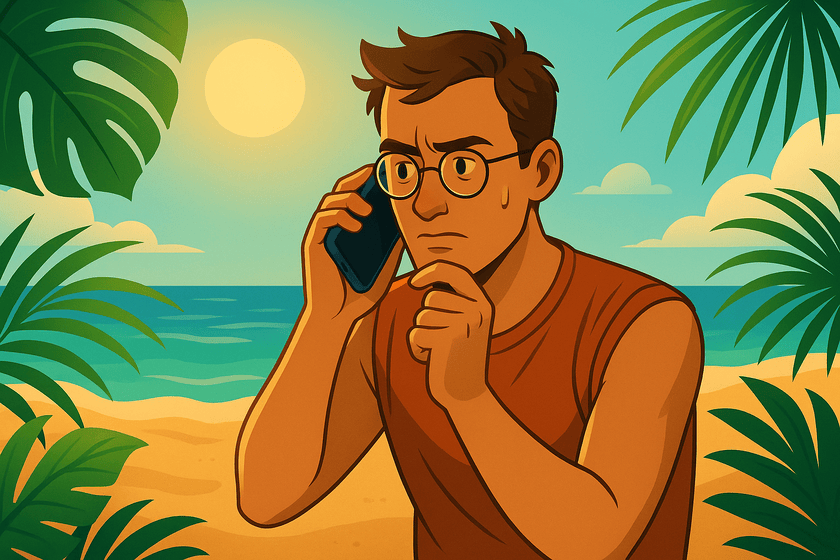

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- **Czy wszystkie kolumny są istotne w kontekście zadania?**
1. nie uważam za szczególnie przydatne liczbę rodzeństwa i małżonków. Chociaż w teorii mogłoby to pomóc w uzupełnieniu danych przy pomocy nazwiska(ważne: wtedy potrzebujemy oddzielić imię i nazwisko, by wyszukiwać po nazwisku)
2. Port w którym wsiadł. By wiedzeć czy pasażer przeżył nie potrzebujemy tych danych.

- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
1. Survived
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- : ✔ ̌Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- ✔ Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- ✔ Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- : ✔ Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- ✔ Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [87]:
titanic_df = pd.read_csv('/content/titanic.csv', index_col='PassengerId')
titanic_df.head()
#wyświetlenie tablicy dla zapoznania się z danymi.

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
titanic_df.Survived.value_counts(normalize=True)
#czyli, większość podróżujących Titaniciem(z tych danych) zginęłą, a dokładnie ok. 62%

,proportion
Survived,
0,0.616162
1,0.383838


In [89]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [90]:
titanic_df["Survived"].isna().sum()
#Każdy pasażer ma przypisany status: nie muszę usuwać żadnych rows.

np.int64(0)

In [91]:
def get_percentage_missing(df, axis):
  """
    Zwraca procent brakujących wartości (NaN) w wierszach lub kolumnach DataFrame.

    df : pandas.DataFrame
        Tabela danych, dla której liczone są braki.

    axis : int
        Oś, względem której obliczane są braki:
        - 0 : procent braków w każdej kolumnie
        - 1 : procent braków w każdym wierszu
  """
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]
get_percentage_missing(titanic_df, axis=1)
#198(na początku) rows z brakującymi danymi.

,0
PassengerId,
1,9.09
3,9.09
5,9.09
6,18.18
8,9.09
...,...
885,9.09
886,18.18
887,9.09


In [92]:
missing_cols_t = get_percentage_missing(titanic_df, axis=0)
missing_cols_t
#Wyznaczamy, ile procent danych są NaN i jak musimy ich wyczyścić.

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


In [93]:
#oddzielę nową kolumnę Decks, ponieważ jest wygodniejsza od Cabins pod
#względen analizy:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df.head()
titanic_df.describe()
titanic_df["Deck"].value_counts()
#czyli, pasażerowie nie są podzieleni po równo. Teraz chcę sprawdzić więź z
#ceną biletów.

,count
Deck,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


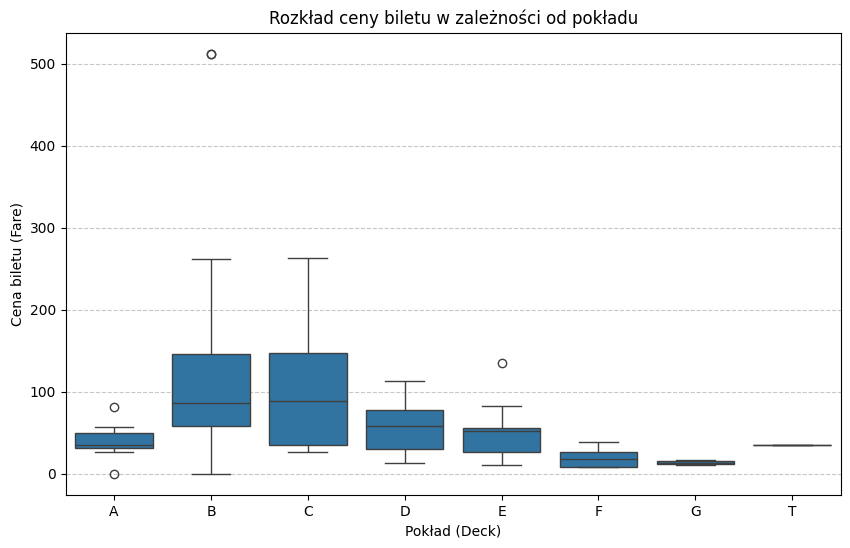

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Deck', y='Fare', data=titanic_df.sort_values('Deck'))
plt.title('Rozkład ceny biletu w zależności od pokładu')
plt.xlabel('Pokład (Deck)')
plt.ylabel('Cena biletu (Fare)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Dany wykres wskazuje korelację pomiędzy ceną biletów a liczebnością pasażerów. Czyli, najwięcej danych uzyskaliśmy od najzamożniejszych.


A jeżeli mówimy o uzupełnieniu, to warto to zrobić przez medianę, ponieważ losowy wybór wprowadziłby dużo zamieszania i szumu.

In [95]:
#Tutaj chciałam zobaczyć dokładne wartości median, chociaż są na wykresie.
median_fare_by_deck = titanic_df.groupby('Deck')['Fare'].median()
median_fare_by_deck

,Fare
Deck,
A,35.50000
B,86.50000
C,89.10420
D,58.22915
E,52.48125
F,17.67915
G,13.58125
T,35.50000


In [96]:
#dlatego, że Fare jest asymetryczna, uzupełniamy NaN przy pomocy mediany:
overall_median_fare = titanic_df['Fare'].median()

titanic_df['Fare'] = titanic_df.groupby('Deck')['Fare'].transform(lambda x: x.fillna(x.median()))
titanic_df['Fare'].fillna(overall_median_fare, inplace=True)

print(titanic_df['Fare'].isna().sum())

0


/tmp/ipykernel_1505/78883256.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Fare'].fillna(overall_median_fare, inplace=True)


In [97]:
#Deck ma ok. 77% brakujących wartości, czyli warto
#dodać nową kategorię Unknown.
titanic_df['Deck'].fillna('Unknown', inplace=True)
titanic_df['Deck'].value_counts()
#sprawdziłam też isna, jest = 0, czyli Deck wypełniona.

/tmp/ipykernel_1505/3905806892.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Deck'].fillna('Unknown', inplace=True)


,count
Deck,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [98]:
#podobnie do Deck, który pochodzi od Cabin, wypełniamy Cabin tym samym Unknown
titanic_df['Cabin'].fillna('Unknown', inplace=True)
titanic_df['Cabin'].isna().sum()

/tmp/ipykernel_1505/665003437.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Cabin'].fillna('Unknown', inplace=True)


np.int64(0)

Uważam to za ciekawe. Czyli, deck A i T były najgroźniejsze.
Ale na T był wyłączne jeden pasażer(znane dane), dlatego dany przypadek nie bierzemy do statystyki(albo błąd, albo zbyt nieliczna grupa). Też jest 77% nieznanych danych, ale jak wcześniej pisałam, są Unknown.

In [99]:
titanic_df["Embarked"].value_counts()
#uzupełniłam w nast. komórce(te colabowe) NaN poprzez modę(najczęstsza wartością występującą)
#ponieważ braków nie jest aż tak dużo oraz zmienna nie wpływa na analizę.
#No bo obiektywnie nie ma znaczenia w którym porcie wsiadł

,count
Embarked,
S,644
C,168
Q,77


In [100]:
mode_embarked = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'].fillna(mode_embarked, inplace=True)

print(f"Brakujące wartości w kolumnie 'Embarked'(po fillna): {titanic_df['Embarked'].isna().sum()}")


Brakujące wartości w kolumnie 'Embarked'(po fillna): 0


/tmp/ipykernel_1505/4063923073.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Embarked'].fillna(mode_embarked, inplace=True)


In [101]:
titanic_df.info()
titanic_df["Deck"].isna().sum()
#używałam tego wykresu, by

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     891 non-null    object 
 10  Embarked  891 non-null    object 
 11  Deck      891 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 90.5+ KB


np.int64(0)

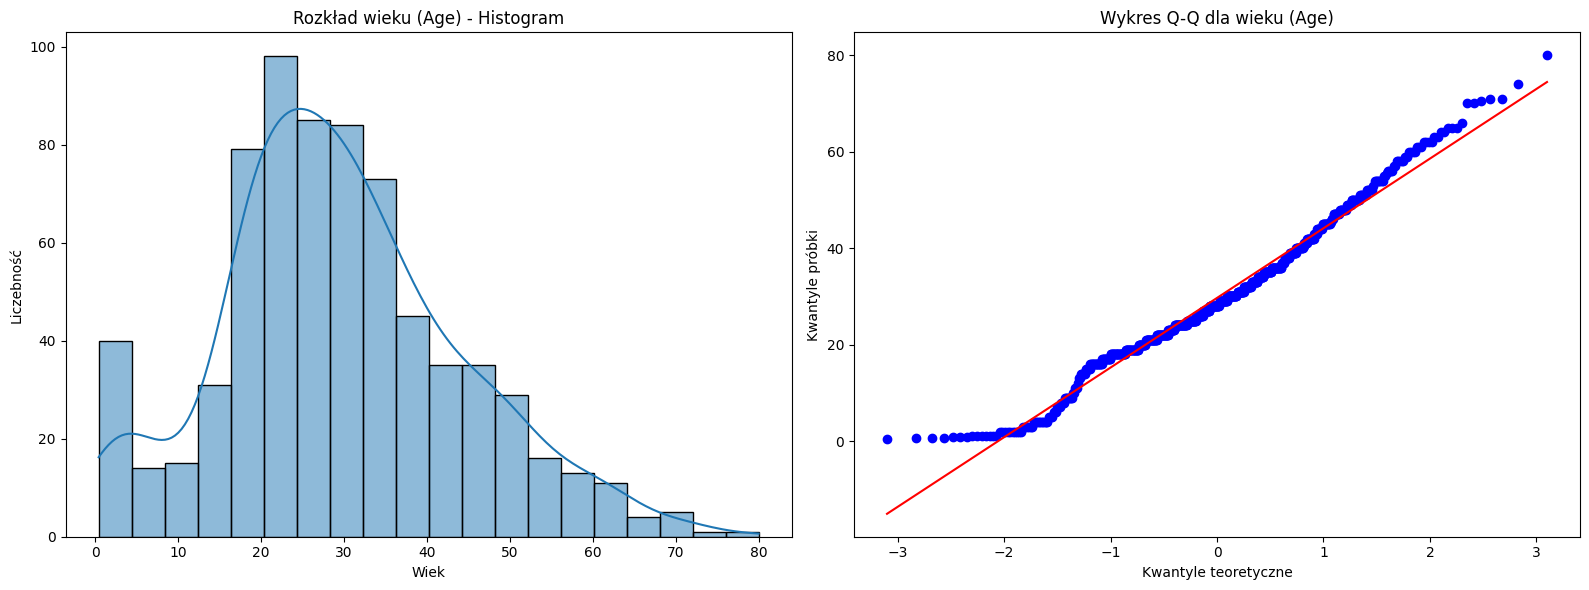

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
#biblioteki importowałam ponownie, bo nie chcę jescze raz puszczać inny wykres.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(titanic_df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Rozkład wieku (Age) - Histogram')
axes[0].set_xlabel('Wiek')
axes[0].set_ylabel('Liczebność')

# Wykres Q-Q
stats.probplot(titanic_df['Age'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Wykres Q-Q dla wieku (Age)')
axes[1].set_xlabel('Kwantyle teoretyczne')
axes[1].set_ylabel('Kwantyle próbki')

plt.tight_layout()
plt.show()

Zależność kolumny "Age" jest asymetryczna(prawoskośny), czyli musimy użyć mediany.

In [103]:
overall_median_age = titanic_df['Age'].median()

titanic_df['Age'].fillna(overall_median_age, inplace=True)

print(f"Brakujące wartości w kolumnie 'Age': {titanic_df['Age'].isna().sum()}")

Brakujące wartości w kolumnie 'Age': 0


/tmp/ipykernel_1505/1322842214.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(overall_median_age, inplace=True)


In [104]:
import re

# wyodrębniamy tytuł z imienia
def get_title(name):
    title_search = re.search(r' ([A-Za-z]+)\.', name)
    # Jeśli tytuł istnieje, wyodrębnij go i zwróć
    if title_search:
        return title_search.group(1)
    return ""

# Nowa zmienna Title
titanic_df['Title'] = titanic_df['Name'].apply(get_title)

print("Unikalne tytuły i ich liczebność:")
display(titanic_df['Title'].value_counts())

Unikalne tytuły i ich liczebność:


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [105]:
top_5_titles = titanic_df['Title'].value_counts().head(5)
titanic_df['Title'] = titanic_df['Title'].apply(lambda x: x if x in top_5_titles else 'Other')
titanic_df['Title'].isna().sum()

np.int64(0)

In [106]:
titanic_df.info()
titanic_df["Deck"].isna().sum()
#używałam tego wykresu, by sprawdzać jak kodować zmienne
#Poprawa: Dobra, tutaj wszystko było dobrze. czyli coś poszło nie tak podczas kodowania.
#Przy kodowaniu trzeba zrobić dod. kolumny by jak robię wykresy nie miałam problemów.

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     891 non-null    object 
 10  Embarked  891 non-null    object 
 11  Deck      891 non-null    object 
 12  Title     891 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 97.5+ KB


np.int64(0)



---


##Kodowanie
Zamieszczę tu wybrane sposoby dla każdej kolumny

0.   Survived(binary, already done)  
1.   Pclass  (ordinal, already done)  
2.   Name    non-coded
 3.   Sex binary(only man/woman, becuase no data was missing + no NonBinary)
 4.   Age bez kodowania
 5.   SibSp (Ordinal, already done)
 6.   Parch (Ordinal, done)   
 7.   Ticket bez kodowania
 8.   Fare bez kodowania
 9.   Cabin bez kodowania
 10.  Embarked (Label)
 11.  Deck     (Label, ale 0 == Unknown)
 12.  Title  (Label)(Other = 4)

 To-do list:

*   ✔ sex
*   ✔ Embarked
*   ✔ Deck
*   ✔ Title




In [107]:
#Mapping sex (encoding)
sex_mapping = {'male': 0, 'female': 1}
titanic_df['Sex_coded'] = titanic_df['Sex'].map(sex_mapping)
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Title,Sex_coded
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,14.5000,Unknown,S,Unknown,Mr,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,Mrs,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,14.5000,Unknown,S,Unknown,Miss,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,Mrs,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,14.5000,Unknown,S,Unknown,Mr,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,14.5000,Unknown,S,Unknown,Other,0
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B,Miss,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,14.5000,Unknown,S,Unknown,Miss,1


In [108]:
#Mapping Embarked (encoding)
embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
titanic_df['Embarked_coded'] = titanic_df['Embarked'].map(embarked_mapping)
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Title,Sex_coded,Embarked_coded
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,14.5000,Unknown,S,Unknown,Mr,0,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,Mrs,1,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,14.5000,Unknown,S,Unknown,Miss,1,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,Mrs,1,0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,14.5000,Unknown,S,Unknown,Mr,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,14.5000,Unknown,S,Unknown,Other,0,0
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B,Miss,1,0
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,14.5000,Unknown,S,Unknown,Miss,1,0


In [109]:
titanic_df["Title"].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Other', 'Dr'], dtype=object)

In [110]:
#Title mapping (encoding)
title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, "Dr":4, 'Other':5 }
titanic_df['Title_coded'] = titanic_df['Title'].map(title_mapping)
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Title,Sex_coded,Embarked_coded,Title_coded
PassengerId,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,14.5000,Unknown,S,Unknown,Mr,0,0,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,Mrs,1,1,2
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,14.5000,Unknown,S,Unknown,Miss,1,0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,Mrs,1,0,2
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,14.5000,Unknown,S,Unknown,Mr,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,14.5000,Unknown,S,Unknown,Other,0,0,5
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B,Miss,1,0,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,14.5000,Unknown,S,Unknown,Miss,1,0,1


In [111]:
titanic_df.to_csv()
#już oczyszczone dane


'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Title,Sex_coded,Embarked_coded,Title_coded\n1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,14.5,Unknown,S,Unknown,Mr,0,0,0\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,C,Mrs,1,1,2\n3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,14.5,Unknown,S,Unknown,Miss,1,0,1\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S,C,Mrs,1,0,2\n5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,14.5,Unknown,S,Unknown,Mr,0,0,0\n6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,14.5,Unknown,Q,Unknown,Mr,0,2,0\n7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,E,Mr,0,0,0\n8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,14.5,Unknown,S,Unknown,Master,0,0,3\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,14.5,Unknown,S,Unknown,Mrs,1,0,2\n10,1,2,"Nasser

In [112]:
titanic_df["Fare"].max()
titanic_df["Fare"].min()
#w cenie biletów są outliery takie, jak 0 albo 500.
#Patrząc na wykres wieku, przedstawiony wcześniej, szczególnych outlierów nie ma.
#Inne zmienne nie mają outlierów.

0.0



---

#WIZUALIZACJA ORAZ DODATKOWE WNIOSKI NA TEMAT ZALEŻNOŚCI ZMIENNYCH

Ważna uwaga:
1. Niektóre kolumny nie będą brane do analizy, ponieważ nie wpływają na wyniki oraz nie ma możliwości przekształcenia tych danych na wykres: Name, Ticket, Cabin.


2. Niektóre wykresy, jak histogram wg. wieku(Age) oraz zależność Deck od Survived są podane WYŻEJ

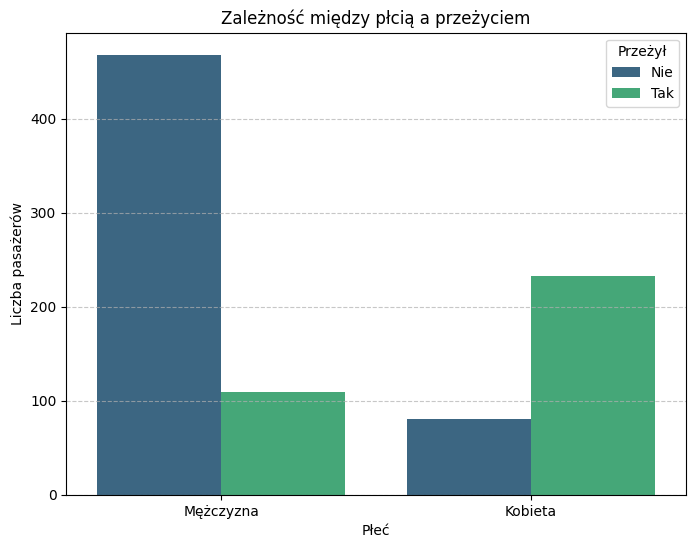

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=titanic_df, palette='viridis')
plt.title('Zależność między płcią a przeżyciem')
plt.xlabel('Płeć')
plt.ylabel('Liczba pasażerów')
plt.xticks(ticks=[0, 1], labels=['Mężczyzna', 'Kobieta'])
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Statystyka po przeżyciu wg. płci jesy prawie w pełni odwrotna do siebie w zależności od płci. Większość kobiet przeżyła, wówczas kiedy większość mężczyzn zginęła.

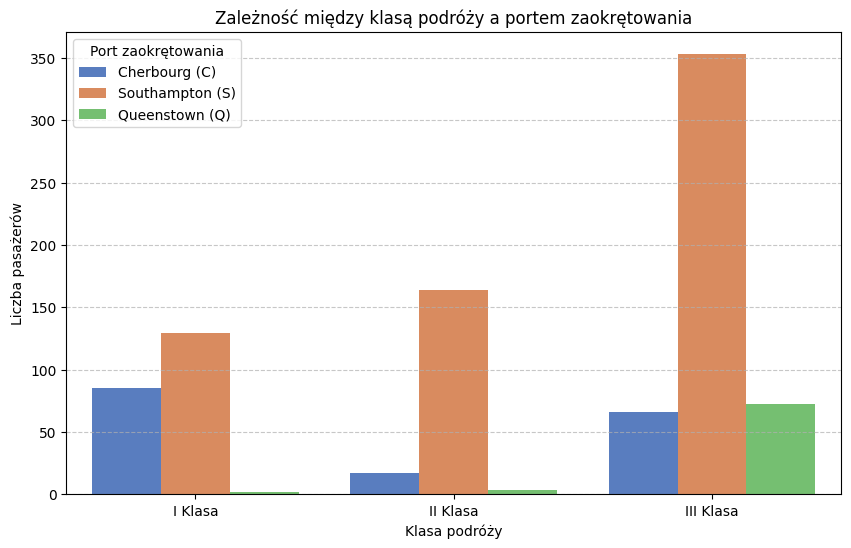

In [114]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Embarked', data=titanic_df, palette='muted')
plt.title('Zależność między klasą podróży a portem zaokrętowania')
plt.xlabel('Klasa podróży')
plt.ylabel('Liczba pasażerów')
plt.xticks(ticks=[0, 1, 2], labels=['I Klasa', 'II Klasa', 'III Klasa'])
plt.legend(title='Port zaokrętowania', labels=['Cherbourg (C)', 'Southampton (S)', 'Queenstown (Q)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ponieważ w Southampton wsiadało najwięcej ludzi, to i spośród wszystkich klas podróży ich było najwięcej. Ale co ciekawe,w Cherbourgu trochę mniej niż połowa pasażerów wsiadali do 1 klasy, podczas gdy z pasażerowie z Queenstown podróżowali najwięcej 3 klasą, co świadczy o niskim dochodzie pasażerów stąd.

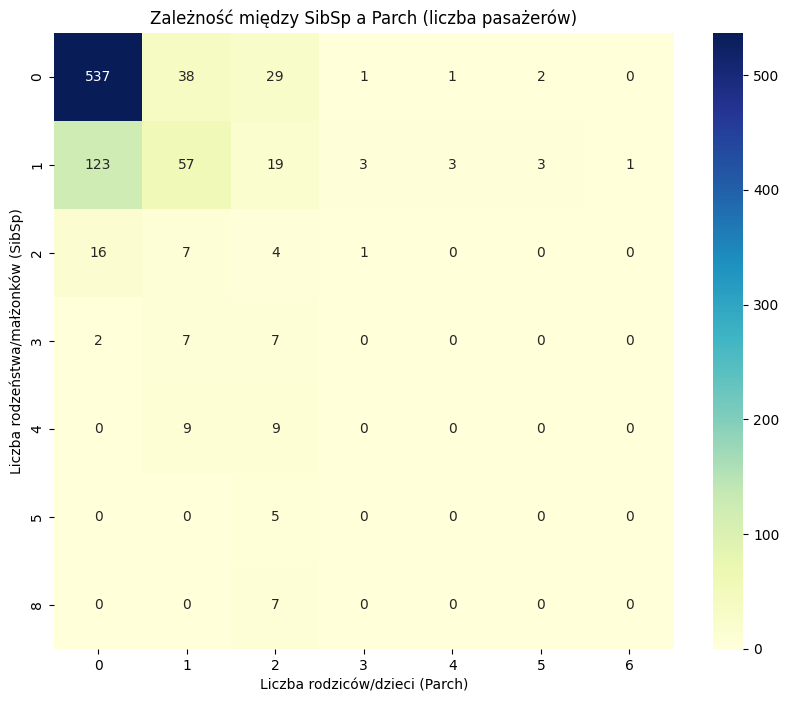

In [115]:
plt.figure(figsize=(10, 8))
correlation_data = pd.crosstab(titanic_df['SibSp'], titanic_df['Parch'])
sns.heatmap(correlation_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Zależność między SibSp a Parch (liczba pasażerów)')
plt.xlabel('Liczba rodziców/dzieci (Parch)')
plt.ylabel('Liczba rodzeństwa/małżonków (SibSp)')
plt.show()

Tutaj ujawniło się wielu outlierów: np. 8 SibSp oraz 2 Parch. Rodziny wtedy były na pewno większe, ale nie na tyle.

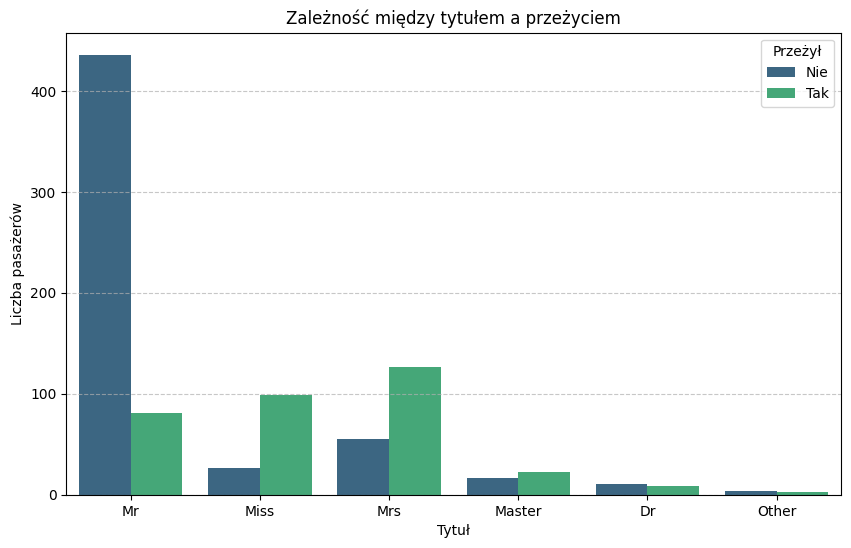

In [116]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Title', hue='Survived', data=titanic_df, palette='viridis')
plt.title('Zależność między tytułem a przeżyciem')
plt.xlabel('Tytuł')
plt.ylabel('Liczba pasażerów')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=['Mr', 'Miss', 'Mrs', 'Master', 'Dr', 'Other'])
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Tutaj raczej podobnie do płci, ponieważ tytuły są do niej przywiązane. Co ciekawe, mężczyzny z tytułem Master przeżywali częściej od innych mężczyzn, chociaż warto zwrócić uwagę też na małą liczebność grupy. Ludzie z rzadszymi tytułami mają szansy prawie 50/50.


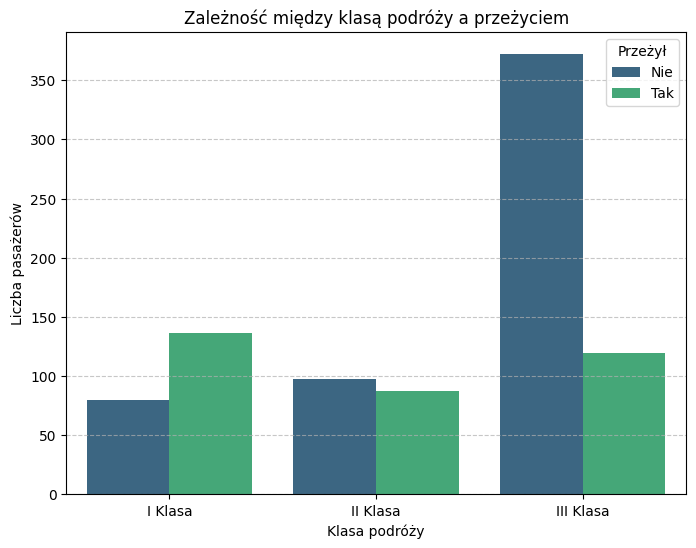

In [117]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=titanic_df, palette='viridis')
plt.title('Zależność między klasą podróży a przeżyciem')
plt.xlabel('Klasa podróży')
plt.ylabel('Liczba pasażerów')
plt.xticks(ticks=[0, 1, 2], labels=['I Klasa', 'II Klasa', 'III Klasa'])
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Klasa, którą podróżowali ludzie wyraźnie pokazuje, że im wyższa klasa, tym więcej ludzi przeżyło, co jest podobne do korelacji zamożności i szansą na przeżycie.

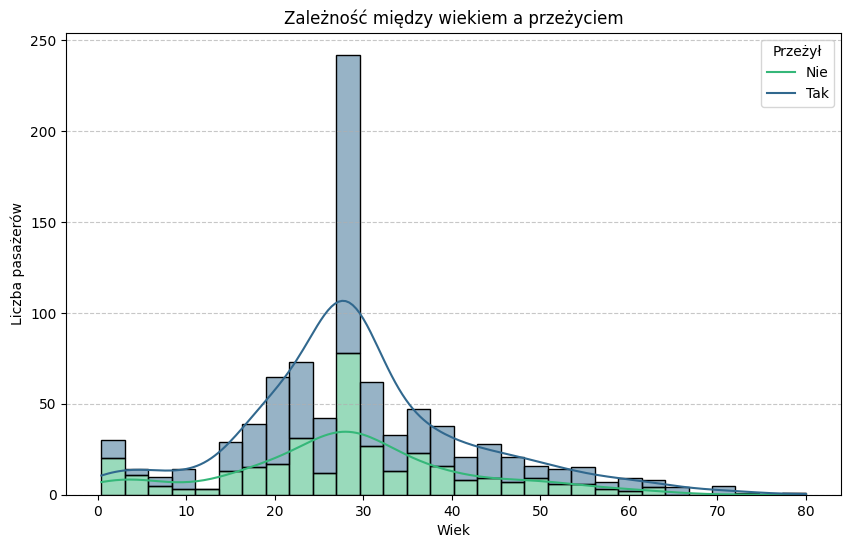

In [118]:
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic_df, x='Age', hue='Survived', multiple='stack', palette='viridis', kde=True)
plt.title('Zależność między wiekiem a przeżyciem')
plt.xlabel('Wiek')
plt.ylabel('Liczba pasażerów')
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#WNIOSKI KOŃCOWE:
- Najbardziej decydującym faktorem dla przeżycia są płeć, wiek i klasa(czyli zamożność).
- Z tego wnioskujemy, że największe szanse na przeżycie mają kobiety, które wykupiły 1 klasę oraz mają w okolicach 30 lat lub są dziećmi do 2-3 lat.
- Może Deck miały znaczenie, ale jest zbyt dużo nieznanych nam danych(77%)